# Fundamental ML Model Architectures

## Binary Image Classification: Cats or Dogs

This notebook trains and fine-tunes model architectures on the **Cat and Dog** dataset from Kaggle.

## 1. Install and Import Libraries

In [12]:
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.preprocessing import image

from sklearn.metrics import confusion_matrix, classification_report

## 2. Locate the Dataset

In [13]:
from pathlib import Path

DATASET_ROOT = Path(".\datasets\cat-and-dog")

print("Dataset root:", DATASET_ROOT)
print("Folders:", [p.name for p in DATASET_ROOT.iterdir() if p.is_dir()])

Dataset root: datasets\cat-and-dog
Folders: ['cats', 'dogs']


## 3. Data Preparation
The training folder is split into:

- 90% training data
- 10% validation data

The test folder is kept separate and only used for final evaluation.

Images are resized to **224×224** pixels so the same size works for both the baseline CNN and MobileNetV2.

In [14]:
IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

train_raw = image_dataset_from_directory(
    DATASET_ROOT,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

temp_raw = image_dataset_from_directory(
    DATASET_ROOT,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

class_names = train_raw.class_names

temp_batches = tf.data.experimental.cardinality(temp_raw).numpy()

validation_raw = temp_raw.take(temp_batches // 2)
test_raw = temp_raw.skip(temp_batches // 2)

Found 2023 files belonging to 2 classes.
Using 1619 files for training.
Found 2023 files belonging to 2 classes.
Using 404 files for validation.


## 4. Inspect Images

This confirms that the data has loaded correctly and that the class labels match the images.

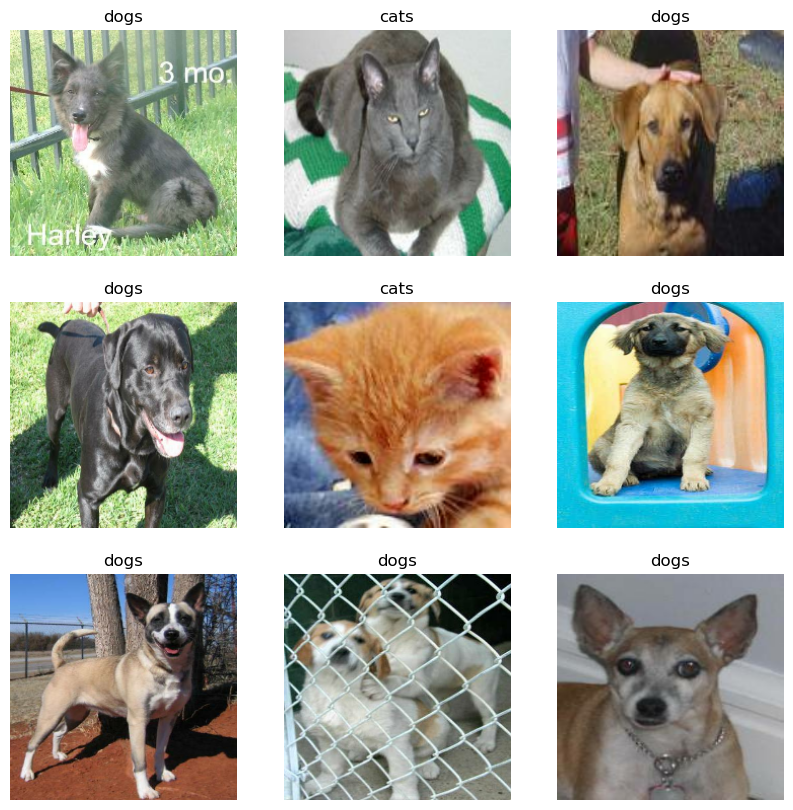

In [15]:
plt.figure(figsize=(10, 10))

for images, labels in train_raw.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[int(labels[i])])
        plt.axis("off")

plt.show()

## 5. Preprocessing Pipelines

Two preprocessing pipelines are created:

1. Baseline CNN: scale pixels from `[0, 255]` to `[0, 1]`
2. MobileNetV2: use the official MobileNetV2 preprocessing function

Caching and prefetching are used to improve training performance.

In [ ]:
def prepare_for_cnn(images, labels):
    images = tf.cast(images, tf.float32) / 255.0
    return images, labels


def prepare_for_mobilenet(images, labels):
    images = tf.cast(images, tf.float32)
    images = preprocess_input(images)
    return images, labels


train_cnn = (
    train_raw
    .map(prepare_for_cnn, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

validation_cnn = (
    validation_raw
    .map(prepare_for_cnn, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

test_cnn = (
    test_raw
    .map(prepare_for_cnn, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)


train_transfer = (
    train_raw
    .map(prepare_for_mobilenet, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

validation_transfer = (
    validation_raw
    .map(prepare_for_mobilenet, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

test_transfer = (
    test_raw
    .map(prepare_for_mobilenet, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)


Preprocessing pipelines created without caching.


## 6. Data Augmentation

Data augmentation creates slightly modified versions of training images during training.

This can reduce overfitting because the model sees more variation.

In [17]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

## 7. Baseline CNN Model

This model is trained from scratch.

This gives a baseline result to compare against transfer learning.

In [18]:
cnn_model = keras.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    data_augmentation,

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(256, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,441 (1.61 MB)

 Trainable params: 421,441 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

## 8. Train the Baseline CNN

The baseline CNN is trained first. Validation loss and validation accuracy are tracked after each epoch.

In [ ]:
CNN_EPOCHS = 10

cnn_history = cnn_model.fit(
    train_cnn,
    validation_data=validation_cnn,
    epochs=CNN_EPOCHS
)

Epoch 1/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 8s 142ms/step - accuracy: 0.4985 - loss: 0.6939 - val_accuracy: 0.4219 - val_loss: 0.6969
Epoch 2/10
39/51 ━━━━━━━━━━━━━━━━━━━━ 1s 134ms/step - accuracy: 0.4736 - loss: 0.6942

## 9. Evaluate the Baseline CNN

The test set is used after training to estimate performance on unseen images.

In [ ]:
cnn_test_loss, cnn_test_accuracy = cnn_model.evaluate(test_cnn)

print(f"CNN test accuracy: {cnn_test_accuracy * 100:.2f}%")
print(f"CNN test loss: {cnn_test_loss:.4f}")

## 10. Transfer Learning with MobileNetV2

MobileNetV2 is used as a pre-trained feature extractor.

The original top/classification layer is removed using `include_top=False`.

At first, the base model is frozen, so only the new classification head is trained.

In [ ]:
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

transfer_model = keras.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    data_augmentation,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

transfer_model.summary()

## 11. Train the Transfer-Learning Model

Only the final classification head is trained in this phase.

In [ ]:
TRANSFER_EPOCHS = 5

transfer_history = transfer_model.fit(
    train_transfer,
    validation_data=validation_transfer,
    epochs=TRANSFER_EPOCHS
)

## 12. Evaluate the Transfer-Learning Model

The transfer-learning model is evaluated on the test set.

In [ ]:
transfer_test_loss, transfer_test_accuracy = transfer_model.evaluate(test_transfer)

print(f"Transfer learning test accuracy: {transfer_test_accuracy * 100:.2f}%")
print(f"Transfer learning test loss: {transfer_test_loss:.4f}")

## 13. Fine-Tuning

Fine-tuning means unfreezing part of the pre-trained MobileNetV2 model and continuing training with a very small learning rate.

The lower layers are kept frozen because they contain general visual features. The upper layers are allowed to adapt to the cat/dog dataset.

In [ ]:
base_model.trainable = True

# Freeze all layers except the last 30 layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.00001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Trainable layers in base model:", sum(layer.trainable for layer in base_model.layers))

## 14. Train the Fine-Tuned Model

The fine-tuned model is trained with a lower learning rate to avoid damaging the pre-trained weights.

In [ ]:
FINE_TUNE_EPOCHS = 5

fine_tune_history = transfer_model.fit(
    train_transfer,
    validation_data=validation_transfer,
    epochs=FINE_TUNE_EPOCHS
)

## 15. Evaluate the Fine-Tuned Model

This is the final model evaluation on the test set.

In [ ]:
fine_tuned_test_loss, fine_tuned_test_accuracy = transfer_model.evaluate(test_transfer)

print(f"Fine-tuned test accuracy: {fine_tuned_test_accuracy * 100:.2f}%")
print(f"Fine-tuned test loss: {fine_tuned_test_loss:.4f}")

## 16. Plot Training Curves

The training curves make it easier to see whether the model is improving, overfitting, or underfitting.

In [ ]:
def plot_history(history, title):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["accuracy"], label="Training accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation accuracy")
    plt.title(title + " - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history.history["loss"], label="Training loss")
    plt.plot(history.history["val_loss"], label="Validation loss")
    plt.title(title + " - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_history(cnn_history, "Baseline CNN")
plot_history(transfer_history, "Transfer Learning")
plot_history(fine_tune_history, "Fine-Tuning")

## 17. Confusion Matrix and Classification Report

In [ ]:
y_true = []
y_pred = []

for images, labels in test_transfer:
    predictions = transfer_model.predict(images, verbose=0)
    predicted_labels = (predictions > 0.5).astype(int).flatten()

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

cm = confusion_matrix(y_true, y_pred)

print("Confusion matrix:")
print(cm)

print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=class_names))

## 18. Visualize Test Predictions

In [ ]:
def sigmoid_to_label_and_confidence(prediction_value):
    probability_class_1 = float(prediction_value)

    if probability_class_1 >= 0.5:
        predicted_index = 1
        confidence = probability_class_1
    else:
        predicted_index = 0
        confidence = 1.0 - probability_class_1

    return predicted_index, confidence


plt.figure(figsize=(12, 12))

for images, labels in test_transfer.take(1):
    predictions = transfer_model.predict(images, verbose=0).flatten()

    # Convert MobileNetV2-preprocessed images back to displayable format
    display_images = (images.numpy() + 1.0) / 2.0
    display_images = np.clip(display_images, 0, 1)

    for i in range(min(9, len(images))):
        predicted_index, confidence = sigmoid_to_label_and_confidence(predictions[i])

        true_label = class_names[int(labels[i])]
        predicted_label = class_names[predicted_index]
        confidence_percent = confidence * 100

        plt.subplot(3, 3, i + 1)
        plt.imshow(display_images[i])
        plt.title(
            f"True: {true_label}\nPred: {predicted_label}\nConfidence: {confidence_percent:.2f}%"
        )
        plt.axis("off")

plt.show()